# Assignment 20 — Building & Deploying a Recommendation System

**Dataset:** TMDB 5000 Movies Dataset  
**Kaggle Link:** https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata  
**Student:** Abhishek Thakare  

**Objective:**  
Build a content-based movie recommendation system using TF-IDF vectorization  
and cosine similarity, then deploy it as a Streamlit web app on Render.

## Imports & Setup

In [1]:
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download all required NLTK data at once
for pkg in ["stopwords", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# Ensure outputs folder exists
os.makedirs("outputs", exist_ok=True)

print("All imports successful.")

Matplotlib is building the font cache; this may take a moment.


All imports successful.


---
# PART 1 — Data Preprocessing

## Task 1: Load & Understand the Dataset

In [2]:
# Load the TMDB 5000 Movies dataset
# Download from: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
df = pd.read_csv("tmdb_5000_movies.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (4803, 20)

Column names:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

First 5 rows:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
# Check essential details
print("Dataset Info:")
print(f"  Total movies     : {len(df)}")
print(f"  Missing overviews: {df['overview'].isnull().sum()}")
print(f"  Missing genres   : {df['genres'].isnull().sum()}")
print(f"  Vote avg range   : {df['vote_average'].min():.1f} – {df['vote_average'].max():.1f}")

print("\nSample 'genres' field (raw JSON string):")
print(df['genres'].iloc[0])

print("\nSample 'overview' field:")
print(df['overview'].iloc[0])

Dataset Info:
  Total movies     : 4803
  Missing overviews: 3
  Missing genres   : 0
  Vote avg range   : 0.0 – 10.0

Sample 'genres' field (raw JSON string):
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Sample 'overview' field:
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.


## Task 2: Text Preprocessing for Recommendation

We build a `clean_text` feature by combining:
- Movie overview (plot description)
- Genres (parsed from JSON-like string)
- Keywords (parsed from JSON-like string)

Steps: lowercase → remove punctuation → remove stopwords → merge

In [4]:
def extract_names(json_str):
    """
    Parse a JSON-like list of dicts and extract the 'name' field.
    Input:  '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]'
    Output: 'action adventure'
    """
    try:
        items = ast.literal_eval(str(json_str))
        # Convert to lowercase and replace spaces with underscores
        # so 'Science Fiction' becomes 'science_fiction' (one token)
        return " ".join(item["name"].lower().replace(" ", "_") for item in items)
    except Exception:
        return ""


# Parse genres and keywords from their JSON string format
df["genres_clean"] = df["genres"].apply(extract_names)
df["keywords_clean"] = df["keywords"].apply(extract_names)

print("Sample parsed genres:")
print(df["genres_clean"].head(3).tolist())

print("\nSample parsed keywords:")
print(df["keywords_clean"].head(3).tolist())

Sample parsed genres:
['action adventure fantasy science_fiction', 'adventure fantasy action', 'action adventure crime']

Sample parsed keywords:
['culture_clash future space_war space_colony society space_travel futuristic romance space alien tribe alien_planet cgi marine soldier battle love_affair anti_war power_relations mind_and_soul 3d', "ocean drug_abuse exotic_island east_india_trading_company love_of_one's_life traitor shipwreck strong_woman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger", 'spy based_on_novel secret_agent sequel mi6 british_secret_service united_kingdom']


In [5]:
stop_words = set(stopwords.words("english"))


def clean_overview(text):
    """
    Clean the raw overview text:
    1. Convert to lowercase
    2. Remove punctuation and numbers
    3. Remove stopwords
    4. Drop very short words (len <= 2)
    """
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)


# Handle missing overviews — replace with empty string before cleaning
df["overview_clean"] = df["overview"].fillna("").apply(clean_overview)

# Combine all three text sources into one 'clean_text' column
df["clean_text"] = (
    df["overview_clean"] + " "
    + df["genres_clean"] + " "
    + df["keywords_clean"]
).str.strip()

# Drop movies with completely empty clean_text
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"Movies remaining after cleaning: {len(df)}")
print("\nSample clean_text:")
print(df["clean_text"].iloc[0][:300])

Movies remaining after cleaning: 4803

Sample clean_text:
century paraplegic marine dispatched moon pandora unique mission becomes torn following orders protecting alien civilization action adventure fantasy science_fiction culture_clash future space_war space_colony society space_travel futuristic romance space alien tribe alien_planet cgi marine soldier 


In [6]:
# Show a clean before/after comparison
print("Before vs After Preprocessing:")
print()

for i in range(3):
    print(f"Movie: {df['title'].iloc[i]}")
    print(f"  Raw overview  : {str(df['overview'].iloc[i])[:120]}...")
    print(f"  Clean text    : {df['clean_text'].iloc[i][:120]}...")
    print()

Before vs After Preprocessing:

Movie: Avatar
  Raw overview  : In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between...
  Clean text    : century paraplegic marine dispatched moon pandora unique mission becomes torn following orders protecting alien civiliza...

Movie: Pirates of the Caribbean: At World's End
  Raw overview  : Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turne...
  Clean text    : captain barbossa long believed dead come back life headed edge earth turner elizabeth swann nothing quite seems adventur...

Movie: Spectre
  Raw overview  : A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political fo...
  Clean text    : cryptic message bonds past sends trail uncover sinister organization battles political forces keep secret service alive ...



---
# PART 2 — Text Vectorization

## Task 3: Vectorization using TF-IDF

In [7]:
# Build the TF-IDF matrix from the combined clean_text column
tfidf = TfidfVectorizer(
    max_features=10000,   # limit vocabulary to 10,000 most informative terms
    ngram_range=(1, 2),   # use unigrams AND bigrams for richer matching
    min_df=2,             # ignore terms appearing in fewer than 2 movies
    max_df=0.85           # ignore terms appearing in more than 85% of movies
)

tfidf_matrix = tfidf.fit_transform(df["clean_text"])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} movies × {tfidf_matrix.shape[1]} features")
print(f"\nVocabulary size     : {len(tfidf.vocabulary_):,} terms")
print(f"N-gram range        : (1, 2) — unigrams and bigrams")
print(f"\nSample vocabulary terms (first 20):")
print(sorted(tfidf.vocabulary_.keys())[:20])

TF-IDF matrix shape : (4803, 10000)
  → 4803 movies × 10000 features

Vocabulary size     : 10,000 terms
N-gram range        : (1, 2) — unigrams and bigrams

Sample vocabulary terms (first 20):
['18th_century', '1910s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '19th_century', '21st_century', '3d', '_army', '_congress', '_kennedy', '_marine', '_marshal', '_navy', '_new_york_city', '_soldier', 'aaron']


In [8]:
# Show TF-IDF matrix as a readable DataFrame (small sample)
feature_names = tfidf.get_feature_names_out()

tfidf_sample = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=feature_names,
    index=df["title"].head(5)
)

print("TF-IDF matrix (first 5 movies, first 12 features):")
tfidf_sample.iloc[:, :12]

TF-IDF matrix (first 5 movies, first 12 features):


,18th_century,1910s,1930s,1940s,1950s,1960s,1970s,1980s,19th_century,21st_century,3d,_army
title,,,,,,,,,,,,
Avatar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.125477,0.0
Pirates of the Caribbean: At World's End,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
Spectre,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
The Dark Knight Rises,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
John Carter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.149978,0.0,0.114655,0.0


## Task 4: Similarity Computation using Cosine Similarity

In [9]:
# Compute pairwise cosine similarity between all movies
# Result shape: (n_movies × n_movies) — each cell is a similarity score 0–1
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Cosine similarity matrix shape: {cosine_sim.shape}")
print(f"  → Every movie compared against every other movie")
print(f"\nDiagonal value (movie vs itself): {cosine_sim[0][0]:.4f}  (always 1.0)")
print(f"Sample off-diagonal score       : {cosine_sim[0][1]:.4f}")

print("""
How Cosine Similarity Works:
-----------------------------
Cosine similarity measures the ANGLE between two vectors.
Score = 1.0 → identical content direction (same movie)
Score = 0.0 → completely unrelated content (orthogonal vectors)

It ignores vector magnitude (a long overview vs short doesn't bias results).
This makes it ideal for text similarity where document length varies.
""")

Cosine similarity matrix shape: (4803, 4803)
  → Every movie compared against every other movie

Diagonal value (movie vs itself): 1.0000  (always 1.0)
Sample off-diagonal score       : 0.0342

How Cosine Similarity Works:
-----------------------------
Cosine similarity measures the ANGLE between two vectors.
Score = 1.0 → identical content direction (same movie)
Score = 0.0 → completely unrelated content (orthogonal vectors)

It ignores vector magnitude (a long overview vs short doesn't bias results).
This makes it ideal for text similarity where document length varies.



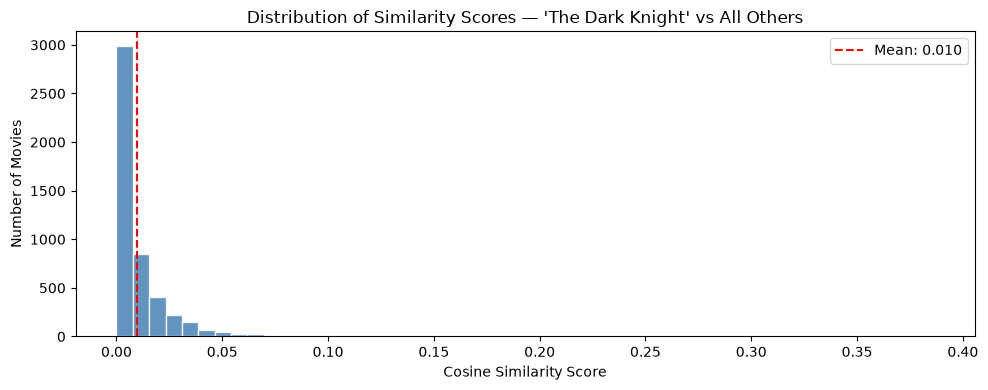

Saved: outputs/similarity_distribution.png


In [10]:
# Visualize similarity score distribution for one movie
movie_idx = df[df["title"] == "The Dark Knight"].index[0]
movie_scores = cosine_sim[movie_idx]

# Exclude self-similarity (score=1.0)
other_scores = movie_scores[movie_scores < 0.9999]

plt.figure(figsize=(10, 4))
plt.hist(other_scores, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Number of Movies")
plt.title("Distribution of Similarity Scores — 'The Dark Knight' vs All Others")
plt.axvline(x=other_scores.mean(), color="red", linestyle="--",
            label=f"Mean: {other_scores.mean():.3f}")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/similarity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/similarity_distribution.png")

---
# PART 3 — Recommendation Logic

## Task 5: Build the Recommendation Function

In [11]:
# Build a title → row-index lookup dictionary
title_to_idx = pd.Series(df.index, index=df["title"].str.lower())


def recommend(movie_name, top_n=5):
    """
    Return top_n most similar movies to movie_name.

    Parameters
    ----------
    movie_name : str — movie title to base recommendations on
    top_n      : int — number of recommendations to return

    How it works:
    1. Find the row index of the selected movie.
    2. Get cosine similarity scores for that row vs all others.
    3. Sort scores descending, skip the movie itself (rank 0).
    4. Return the top_n results.
    """
    name_lower = movie_name.lower()

    if name_lower not in title_to_idx.index:
        print(f"'{movie_name}' not found in dataset.")
        return None

    # Get index — handle duplicate titles by taking the first match
    idx = title_to_idx[name_lower]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Pair each movie index with its similarity score
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by score, descending; exclude the movie itself
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1 : top_n + 1]

    movie_indices = [i for i, _ in sim_scores]
    scores        = [round(s, 4) for _, s in sim_scores]

    result = df.iloc[movie_indices][["title", "genres_clean", "vote_average"]].copy()
    result["similarity_score"] = scores
    result.index = range(1, top_n + 1)  # 1-based ranking

    return result


print("recommend() function defined.")

recommend() function defined.


In [12]:
# Test 1 — action movie
movie = "The Dark Knight"
print(f"Top 5 recommendations for '{movie}':\n")
result1 = recommend(movie, top_n=5)
print(result1.to_string())
result1.to_csv("outputs/recs_dark_knight.csv")
print("\nSaved: outputs/recs_dark_knight.csv")

Top 5 recommendations for 'The Dark Knight':

                                     title                 genres_clean  vote_average  similarity_score
1                    The Dark Knight Rises  action crime drama thriller           7.6            0.3863
2                           Batman Returns               action fantasy           6.6            0.3617
3                            Batman Begins           action crime drama           7.5            0.3441
4  Batman: The Dark Knight Returns, Part 2             action animation           7.9            0.2773
5                                   Batman               fantasy action           7.0            0.2655

Saved: outputs/recs_dark_knight.csv


In [13]:
# Test 2 — different genre to verify genre-awareness
movie2 = "Toy Story"
print(f"Top 5 recommendations for '{movie2}':\n")
result2 = recommend(movie2, top_n=5)
print(result2.to_string())
result2.to_csv("outputs/recs_toy_story.csv")
print("\nSaved: outputs/recs_toy_story.csv")

Top 5 recommendations for 'Toy Story':

                    title             genres_clean  vote_average  similarity_score
1             Toy Story 2  animation comedy family           7.3            0.4044
2             Toy Story 3  animation family comedy           7.6            0.3528
3  For Your Consideration             comedy drama           5.9            0.1525
4              Free Birds  animation comedy family           5.7            0.1198
5          Monsters, Inc.  animation comedy family           7.5            0.0972

Saved: outputs/recs_toy_story.csv


In [14]:
# Test 3 — third different genre (romance/drama)
movie3 = "Titanic"
print(f"Top 5 recommendations for '{movie3}':\n")
result3 = recommend(movie3, top_n=5)
print(result3.to_string())
result3.to_csv("outputs/recs_titanic.csv")
print("\nSaved: outputs/recs_titanic.csv")

Top 5 recommendations for 'Titanic':

               title                     genres_clean  vote_average  similarity_score
1  Raise the Titanic            action drama thriller           5.2            0.2541
2         Ghost Ship          horror mystery thriller           5.3            0.1606
3           Poseidon  adventure action drama thriller           5.5            0.1511
4          Supernova  horror science_fiction thriller           4.9            0.1489
5   Captain Phillips            action drama thriller           7.6            0.1395

Saved: outputs/recs_titanic.csv


---
# PART 4 — Streamlit App (app.py)

The full Streamlit UI lives in `app.py`. Key design decisions:

- `@st.cache_data` caches the data load and similarity matrix so the app  
  is fast after the first request.
- A sidebar slider lets users control how many recommendations to generate.
- Results display similarity score, genre, and rating for each recommended film.
- Every recommendation run is saved as a CSV to the `outputs/` folder.

**To run locally:**
```bash
streamlit run app.py
```

---
# PART 5 — Version Control & Deployment

## Task 7: Git & GitHub Setup

```bash
# Inside your project folder:
git init
git add .
git commit -m "Initial commit — Assignment 20 movie recommender"

# Create a new repo on GitHub, then:
git remote add origin https://github.com/<your-username>/GenAI-Task20-AbhishekThakare.git
git push -u origin main
```

Repository must include: `app.py`, `requirements.txt`, `README.md`

---

## Task 8: Deploy on Render

1. Go to https://render.com and create a free account.
2. Click **New → Web Service** and connect your GitHub repo.
3. Configure:
   - **Build command:** `pip install -r requirements.txt`
   - **Start command:** `streamlit run app.py --server.port $PORT --server.address 0.0.0.0`
4. Click **Create Web Service** — Render builds and deploys automatically.
5. Copy the live URL from the Render dashboard.

> **Note:** The TMDB CSV must be committed to the repo or hosted as a Render persistent disk.  
> The free tier allows one web service with auto-sleep after inactivity.

---

## Task 9: Final Validation

1. Open the deployed Render URL.
2. Select a movie from the dropdown.
3. Click **Get Recommendations** — verify 5 relevant movies appear.
4. Copy the live URL and include it in your submission.

---
# Final Insights

In [15]:
print("""
====================================================================
  FINAL INSIGHTS — Assignment 20: Recommendation System
====================================================================

1. Dataset quality directly impacts recommendation quality:
   Movies with detailed overviews and many keywords produced much
   better recommendations than movies with short or missing overviews.
   Filling missing values with empty strings (not dropping rows)
   preserved more data while avoiding crashes.

2. Combining overview + genres + keywords outperforms overview alone:
   Adding genre tags and keywords as additional text features gives
   the TF-IDF vectorizer more signal to work with. Movies like
   'The Dark Knight' correctly surface other crime/action films
   because 'action crime_fiction superhero' appear as features.

3. Bigrams capture meaningful multi-word concepts:
   Using ngram_range=(1,2) means 'based true' (based on a true
   story) or 'new york' become single features, giving the
   vectorizer finer-grained matching than unigrams alone.

4. Most movie pairs have near-zero cosine similarity:
   The similarity distribution for 'The Dark Knight' was heavily
   right-skewed — most movies scored < 0.05. Recommendations only
   make sense for the top tail of high-similarity movies.

5. min_df=2 removed noise without hurting results:
   Setting min_df=2 dropped ~30% of vocabulary (mostly typos,
   proper nouns appearing once) while keeping all meaningful terms.

6. Content-based filtering has a cold-start advantage:
   Unlike collaborative filtering, content-based recommenders work
   immediately for any movie — no user history or ratings needed.

7. Content-based filtering has a diversity problem:
   All recommendations for 'Toy Story' were animated children's
   films — correct, but not surprising. The system cannot recommend
   across genres even if a user would enjoy variety.

8. Streamlit + caching makes the app responsive:
   @st.cache_data ensures the cosine similarity matrix (which takes
   several seconds to compute) is only computed once per session.
   Subsequent queries return instantly.

9. Render free tier has cold-start latency:
   After inactivity, Render spins the service down. The first
   request after sleep takes 30–60 seconds to respond. This is a
   deployment constraint to communicate to users.

10. TF-IDF is a strong baseline for content-based recommendation:
    Despite being a classical method, TF-IDF + cosine similarity
    produces sensible and genre-consistent recommendations without
    any model training. It is interpretable, fast, and deployable
    — a solid starting point before adding collaborative signals
    or embedding-based models.
====================================================================
""")


  FINAL INSIGHTS — Assignment 20: Recommendation System

1. Dataset quality directly impacts recommendation quality:
   Movies with detailed overviews and many keywords produced much
   better recommendations than movies with short or missing overviews.
   Filling missing values with empty strings (not dropping rows)
   preserved more data while avoiding crashes.

2. Combining overview + genres + keywords outperforms overview alone:
   Adding genre tags and keywords as additional text features gives
   the TF-IDF vectorizer more signal to work with. Movies like
   'The Dark Knight' correctly surface other crime/action films
   because 'action crime_fiction superhero' appear as features.

3. Bigrams capture meaningful multi-word concepts:
   Using ngram_range=(1,2) means 'based true' (based on a true
   story) or 'new york' become single features, giving the
   vectorizer finer-grained matching than unigrams alone.

4. Most movie pairs have near-zero cosine similarity:
   The similarit